In [75]:
import datetime
print(f"Notebook last executed(end to end):{(datetime.datetime.now())}")

Notebook last executed(end to end):2026-03-18 19:48:17.899508


In [76]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Data Processing

In [77]:
insurance=pd.read_csv("insurance.csv")

In [78]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [79]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [80]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [81]:
#convert categorical values into numbers
insurance_one_hot=pd.get_dummies(insurance)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [82]:
insurance.shape

(1338, 7)

In [83]:
#checking for missing values
insurance.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [84]:
#splitting data into features and label
X = insurance_one_hot.drop("charges", axis=1)
y = insurance_one_hot["charges"]
X.head(),y.head()

(   age     bmi  children  sex_female  sex_male  smoker_no  smoker_yes  \
 0   19  27.900         0        True     False      False        True   
 1   18  33.770         1       False      True       True       False   
 2   28  33.000         3       False      True       True       False   
 3   33  22.705         0       False      True       True       False   
 4   32  28.880         0       False      True       True       False   
 
    region_northeast  region_northwest  region_southeast  region_southwest  
 0             False             False             False              True  
 1             False             False              True             False  
 2             False             False              True             False  
 3             False              True             False             False  
 4             False              True             False             False  ,
 0    16884.92400
 1     1725.55230
 2     4449.46200
 3    21984.47061
 4     3866.85520
 

In [85]:
#splitting data into test and train
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [86]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1070, 11), (268, 11), (1070,), (268,))

In [87]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [88]:
# Reshape y to be 2D (num_samples, 1)
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

print(y_train.shape, y_test.shape)
# Output: (1070, 1) (268, 1)

(1070, 1) (268, 1)


Modeling


In [89]:
# Set random seed
tf.random.set_seed(42)

# Create a new model (same as model_2)
insurance_model = tf.keras.Sequential([
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1)
])

# Compile the model
insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=['mae'])

# Fit the model
insurance_model.fit(X_train, y_train, epochs=500,verbose=0)

In [90]:
# Check the results of the insurance model
insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3166.2063 - mae: 3166.2063 


[3166.206298828125, 3166.206298828125]

In [97]:
# Set random seed
tf.random.set_seed(42)

# Improved Neural Network for Regression
insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),  # more units, relu
    tf.keras.layers.Dense(64, activation='relu'),                                     # hidden layer
    tf.keras.layers.Dense(32, activation='relu'),                                     # hidden layer
    tf.keras.layers.Dense(1)                                                          # output layer (linear)
])

# Compile the model with Adam optimizer and a slightly smaller learning rate
insurance_model_2.compile(
    loss=tf.keras.losses.Huber(),           # Huber loss is robust to outliers
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['mae']
)

# Early stopping to prevent overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,      # stop if validation loss doesn't improve for 20 epochs
    restore_best_weights=True
)

# Fit the model
history = insurance_model_2.fit(
    X_train, y_train,
    epochs=500,             # more epochs since early stopping will control overfitting
    validation_split=0.2,   # use 20% of training data for validation
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 13516.4629 - mae: 13516.9629 - val_loss: 12650.0195 - val_mae: 12650.5195
Epoch 2/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13502.6738 - mae: 13503.1738 - val_loss: 12618.6055 - val_mae: 12619.1055
Epoch 3/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13427.9824 - mae: 13428.4824 - val_loss: 12472.2939 - val_mae: 12472.7939
Epoch 4/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13150.1865 - mae: 13150.6865 - val_loss: 12004.6709 - val_mae: 12005.1709
Epoch 5/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12393.2598 - mae: 12393.7598 - val_loss: 10876.9121 - val_mae: 10877.4121
Epoch 6/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10899.2617 - mae: 10899.7617 - val_loss: 9269.0176 - val_mae: 9269.5176
Epoch 7/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9112.3975 - mae: 9112.8975 - val_loss: 8028.0474 - val_mae: 8028.5474
Epoch 8/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8108.2310 - mae: 8108.7310 

In [98]:
# Evaluate our larger model
insurance_model_2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1769.3833 - mae: 1769.8748 


[1769.38330078125, 1769.874755859375]

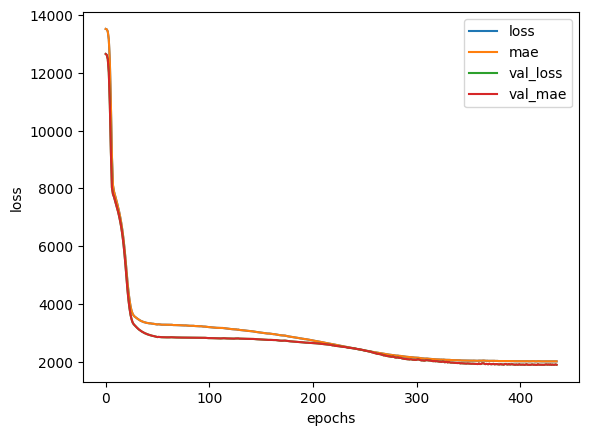

In [99]:
# Plot history (also known as a loss curve)
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs");

In [100]:
from sklearn.metrics import r2_score
y_pred = insurance_model_2.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
R² Score: 0.8633232170762646
